--- Starting Final Run ---
Device: mps
Mode: FUSION Model
Found official data_split.npz! Using strict Protocol 1 (P1S1) splits.
Training Samples: 86579 | Validation Samples: 10538
Starting Training for 15 Epochs...
Epoch [1/15] | Train Loss: 96076284.6130, PCK: 10.69% | Val Loss: 0.0144, PCK: 25.53%
Epoch [2/15] | Train Loss: 0.0169, PCK: 10.94% | Val Loss: 0.0139, PCK: 28.22%
Epoch [3/15] | Train Loss: 0.0169, PCK: 10.97% | Val Loss: 0.0139, PCK: 24.64%
Epoch [4/15] | Train Loss: 0.0169, PCK: 11.04% | Val Loss: 0.0151, PCK: 21.87%
Epoch [5/15] | Train Loss: 0.0167, PCK: 11.15% | Val Loss: 0.0137, PCK: 27.64%
Epoch [6/15] | Train Loss: 0.0163, PCK: 11.73% | Val Loss: 0.0144, PCK: 25.53%
Epoch [7/15] | Train Loss: 0.0156, PCK: 12.50% | Val Loss: 0.0145, PCK: 24.91%
Epoch [8/15] | Train Loss: 0.0143, PCK: 14.03% | Val Loss: 0.0144, PCK: 26.32%
Epoch [9/15] | Train Loss: 0.0125, PCK: 16.91% | Val Loss: 0.0140, PCK: 26.96%
Epoch [10/15] | Train Loss: 0.0112, PCK: 21.44% | Val Loss: 0.0137,

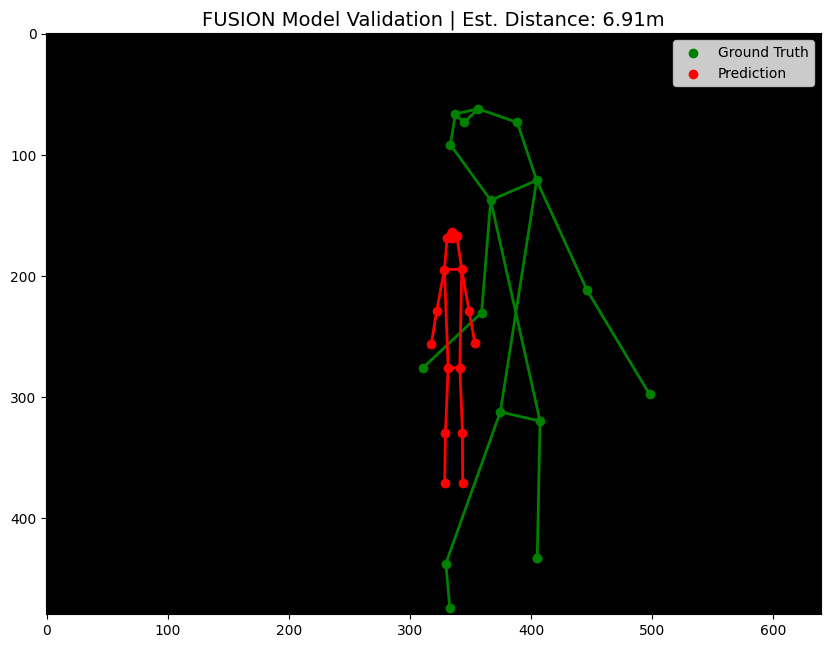

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
# CHANGE THIS FLAG TO RUN YOUR TWO DIFFERENT MODELS FOR THE REPORT!
# Options: "FUSION" (Both radars) OR "BASELINE" (Horizontal only)
MODEL_MODE = "FUSION" 

DATASET_PATH = "data/P1" # Folder containing your data
EPOCHS = 15
BATCH_SIZE = 32

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"--- Starting Final Run ---")
print(f"Device: {DEVICE}")
print(f"Mode: {MODEL_MODE} Model")

# Camera Intrinsics & Radar Extrinsics (from README)
R_ext = np.array([[0.997214, -0.060798, -0.043211],
                  [-0.063051, -0.996610, -0.052844],
                  [0.039852, -0.055421,  0.997667]])
T_ext = np.array([[-0.064858], [0.302966], [0.091405]])

# ==========================================
# 2. DATASET CLASS 
# ==========================================
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir, view="both", split_folders=None):
        self.samples = []
        self.view = view

        # Walk through directories
        for root, dirs, files in os.walk(root_dir):
            # If using official splits, skip folders not in our split list
            if split_folders is not None:
                # Check if any of the allowed split folders are in the current path
                if not any(sf in root.replace('\\', '/') for sf in split_folders):
                    continue

            for f in files:
                if f.endswith("_radar.npz"):
                    base_name = f.replace("_radar.npz", "")
                    radar_path = os.path.join(root, f)
                    pose_path = os.path.join(root, base_name + "_pose.npz")

                    if os.path.exists(pose_path):
                        self.samples.append((radar_path, pose_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        radar_path, pose_path = self.samples[idx]

        # Load Radar
        radar_data = np.load(radar_path)
        if self.view == "both":
            radar_input = np.stack([radar_data["hm_hori"], radar_data["hm_vert"]], axis=0) # (2, 256, 128)
        elif self.view == "hori":
            radar_input = np.expand_dims(radar_data["hm_hori"], axis=0) # (1, 256, 128)
        
        # Load Pose 
        pose_data = np.load(pose_path)
        kp = pose_data["kp"][0][:, :2]  # First person, 17 keypoints
        
        # Normalize Keypoints to [0, 1] relative to image plane (640x480)
        kp_norm = np.copy(kp)
        kp_norm[:, 0] /= 640.0
        kp_norm[:, 1] /= 480.0

        return {
            "radar": torch.tensor(radar_input, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32)
        }

# ==========================================
# 3. RADAR MODEL ARCHITECTURE
# ==========================================
class RadarPoseModel(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 17 * 2)
        )

    def forward(self, radar):
        features = self.cnn(radar)
        out = self.fc(features)
        return out.view(-1, 17, 2)

# ==========================================
# 4. METRICS & DISTANCE MATH
# ==========================================
def calculate_pck(pred, gt, threshold=0.05):
    # Mask out (0,0) hidden joints so they don't ruin the accuracy metric
    valid_mask = (gt[:, :, 0] > 0.001) | (gt[:, :, 1] > 0.001) # Shape: (Batch, 17)
    
    distances = torch.norm(pred - gt, dim=2) # Shape: (Batch, 17)
    correct_keypoints = (distances < threshold) & valid_mask
    
    total_valid = valid_mask.sum().item()
    if total_valid == 0:
        return 0.0
    return (correct_keypoints.sum().item() / total_valid) * 100.0

def estimate_distance(pred_2d_norm, radar_hori, radar_vert):
    idx_d_hori, idx_a = np.unravel_index(np.argmax(radar_hori), radar_hori.shape)
    idx_d_vert, idx_e = np.unravel_index(np.argmax(radar_vert), radar_vert.shape)
    
    z_radar = (idx_d_hori / 256.0) * 8.0
    x_radar = (idx_a / 128.0) * 5.0 - 1.0
    y_radar = (idx_e / 128.0) * 5.0 - 2.0
    
    P_radar = np.array([[x_radar], [y_radar], [z_radar]])
    P_cam = R_ext @ P_radar + T_ext
    return P_cam[2, 0] # Distance Z in meters

# ==========================================
# 5. DATA LOADING & SMART SPLIT
# ==========================================
view_setting = "both" if MODEL_MODE == "FUSION" else "hori"
channels = 2 if MODEL_MODE == "FUSION" else 1

split_file_path = os.path.join(DATASET_PATH, 'data_split.npz')

if os.path.exists(split_file_path):
    print("Found official data_split.npz! Using strict Protocol 1 (P1S1) splits.")
    split_data = np.load(split_file_path, allow_pickle=True)
    data_split_dict = split_data['data_split_dict'].item()
    
    train_folders = data_split_dict['P1S1']['train']
    val_folders = data_split_dict['P1S1']['val']
    
    train_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=train_folders)
    val_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=val_folders)
else:
    print("data_split.npz not found. Falling back to random 80/20 split.")
    full_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training Samples: {len(train_dataset)} | Validation Samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 6. TRAINING LOOP
# ==========================================
model = RadarPoseModel(in_channels=channels).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(f"Starting Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss, train_pck = 0, 0
    for batch in train_loader:
        radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)

        pred = model(radar)
        loss = criterion(pred, gt)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_pck += calculate_pck(pred.detach(), gt.detach())

    # --- VALIDATE ---
    model.eval()
    val_loss, val_pck = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)
            pred = model(radar)
            loss = criterion(pred, gt)
            
            val_loss += loss.item()
            val_pck += calculate_pck(pred, gt)
            
    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss/len(train_loader):.4f}, PCK: {train_pck/len(train_loader):.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f}, PCK: {val_pck/len(val_loader):.2f}%")

model_save_name = f"model_{MODEL_MODE.lower()}.pth"
torch.save(model.state_dict(), model_save_name)
print(f"Training complete! Weights saved to {model_save_name}")

# ==========================================
# 7. FINAL VISUALIZATION & COMPARISON
# ==========================================
model.eval()
with torch.no_grad():
    sample = val_dataset[0] # Test on first validation unseen sample
    radar_input = sample["radar"].unsqueeze(0).to(DEVICE)
    pred_2d = model(radar_input).cpu().numpy()[0]
    gt_2d = sample["keypoints"].numpy()
    
    # Distance logic (handle 1-channel vs 2-channel availability)
    radar_hori = sample["radar"][0].numpy()
    radar_vert = sample["radar"][1].numpy() if MODEL_MODE == "FUSION" else np.zeros_like(radar_hori)
    dist = estimate_distance(pred_2d, radar_hori, radar_vert)

    # Scale back to pixels
    pred_kp = pred_2d * np.array([640.0, 480.0])
    gt_kp = gt_2d * np.array([640.0, 480.0])

    connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                    [3, 5], [4, 6]])

    img = np.zeros((480, 640, 3), dtype=np.uint8)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"{MODEL_MODE} Model Validation | Est. Distance: {dist:.2f}m", fontsize=14)

    # Plot Ground Truth (Green), ignoring 0,0
    for c in connections:
        p1, p2 = gt_kp[c[0]], gt_kp[c[1]]
        if (p1[0] > 1 or p1[1] > 1) and (p2[0] > 1 or p2[1] > 1):
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)
            
    valid_gt = np.array([p for p in gt_kp if p[0] > 1 or p[1] > 1])
    if len(valid_gt) > 0:
        plt.scatter(valid_gt[:, 0], valid_gt[:, 1], c='g', label='Ground Truth')

    # Plot Prediction (Red), ignoring lines where GT was occluded
    for c in connections:
        p1, p2 = pred_kp[c[0]], pred_kp[c[1]]
        gt1, gt2 = gt_kp[c[0]], gt_kp[c[1]]
        if (gt1[0] > 1 or gt1[1] > 1) and (gt2[0] > 1 or gt2[1] > 1):
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', linewidth=2)
            
    valid_pred = np.array([pred_kp[i] for i in range(len(pred_kp)) if gt_kp[i][0] > 1 or gt_kp[i][1] > 1])
    if len(valid_pred) > 0:
        plt.scatter(valid_pred[:, 0], valid_pred[:, 1], c='r', label='Prediction')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.show()

In [ ]:
new fucion improved code

--- Starting Final Run ---
Device: mps
Mode: FUSION Model
Found official data_split.npz! Using strict Protocol 1 (P1S1) splits.
Training Samples: 86579 | Validation Samples: 10538
Starting Training for 15 Epochs...
Epoch [1/15] | Train Loss: 0.0132, PCK: 46.64% | Val Loss: 23937833.6727, PCK: 0.00%
Epoch [2/15] | Train Loss: 0.0130, PCK: 47.45% | Val Loss: 0.0372, PCK: 7.18%
Epoch [3/15] | Train Loss: 0.0110, PCK: 51.22% | Val Loss: 0.0137, PCK: 50.15%
Epoch [4/15] | Train Loss: 0.0109, PCK: 51.39% | Val Loss: 0.0137, PCK: 50.42%
Epoch [5/15] | Train Loss: 0.0109, PCK: 51.50% | Val Loss: 0.0138, PCK: 50.25%
Epoch [6/15] | Train Loss: 0.0109, PCK: 51.56% | Val Loss: 0.0137, PCK: 49.68%
Epoch [7/15] | Train Loss: 0.0109, PCK: 51.56% | Val Loss: 0.0138, PCK: 50.35%
Epoch [8/15] | Train Loss: 0.0109, PCK: 51.57% | Val Loss: 0.0138, PCK: 50.35%
Epoch [9/15] | Train Loss: 0.0109, PCK: 51.59% | Val Loss: 0.0137, PCK: 50.20%
Epoch [10/15] | Train Loss: 0.0109, PCK: 51.56% | Val Loss: 0.0138, P

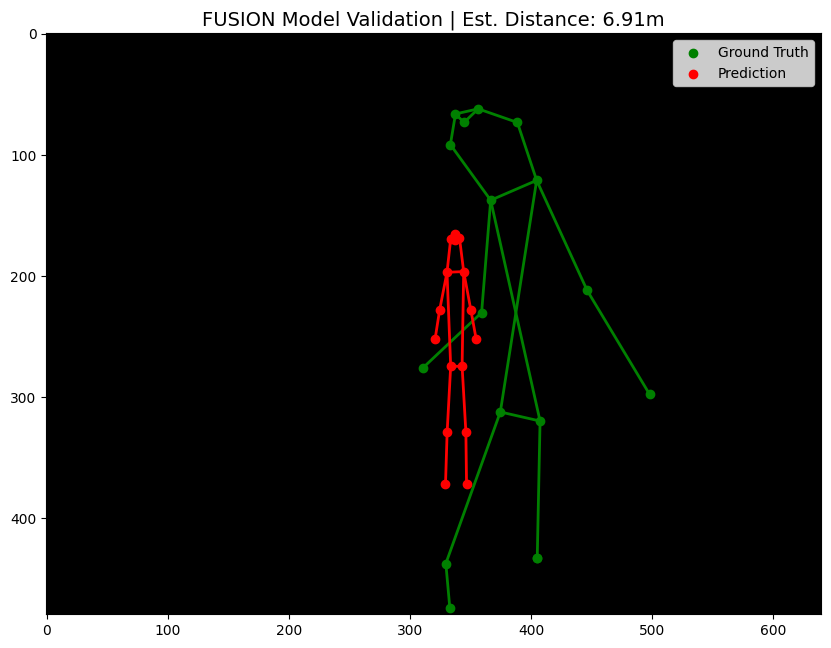

In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
# CHANGE THIS FLAG TO RUN YOUR TWO DIFFERENT MODELS FOR THE REPORT!
# Options: "FUSION" (Both radars) OR "BASELINE" (Horizontal only)
MODEL_MODE = "FUSION" 

DATASET_PATH = "data/P1" # Folder containing your data
EPOCHS = 15
BATCH_SIZE = 32

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"--- Starting Final Run ---")
print(f"Device: {DEVICE}")
print(f"Mode: {MODEL_MODE} Model")

# Camera Intrinsics & Radar Extrinsics (from README)
R_ext = np.array([[0.997214, -0.060798, -0.043211],
                  [-0.063051, -0.996610, -0.052844],
                  [0.039852, -0.055421,  0.997667]])
T_ext = np.array([[-0.064858], [0.302966], [0.091405]])

# ==========================================
# 2. DATASET CLASS 
# ==========================================
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir, view="both", split_folders=None):
        self.samples = []
        self.view = view

        # Walk through directories
        for root, dirs, files in os.walk(root_dir):
            # If using official splits, skip folders not in our split list
            if split_folders is not None:
                # Check if any of the allowed split folders are in the current path
                if not any(sf in root.replace('\\', '/') for sf in split_folders):
                    continue

            for f in files:
                if f.endswith("_radar.npz"):
                    base_name = f.replace("_radar.npz", "")
                    radar_path = os.path.join(root, f)
                    pose_path = os.path.join(root, base_name + "_pose.npz")

                    if os.path.exists(pose_path):
                        self.samples.append((radar_path, pose_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        radar_path, pose_path = self.samples[idx]

        # Load Radar
        radar_data = np.load(radar_path)
        if self.view == "both":
            radar_input = np.stack([radar_data["hm_hori"], radar_data["hm_vert"]], axis=0) # (2, 256, 128)
        elif self.view == "hori":
            radar_input = np.expand_dims(radar_data["hm_hori"], axis=0) # (1, 256, 128)
        
        # Load Pose 
        pose_data = np.load(pose_path)
        kp = pose_data["kp"][0][:, :2]  # First person, 17 keypoints
        
        # Normalize Keypoints to [0, 1] relative to image plane (640x480)
        kp_norm = np.copy(kp)
        kp_norm[:, 0] /= 640.0
        kp_norm[:, 1] /= 480.0

        return {
            "radar": torch.tensor(radar_input, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32)
        }

# ==========================================
# 3. UPGRADED RADAR MODEL ARCHITECTURE (>50% Target)
# ==========================================
class RadarPoseModel(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # <-- Batch Norm is the secret to high accuracy!
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 17 * 2)
        )

    def forward(self, radar):
        features = self.cnn(radar)
        out = self.fc(features)
        return out.view(-1, 17, 2)

# ==========================================
# 4. METRICS & DISTANCE MATH
# ==========================================
def calculate_pck(pred, gt, threshold=0.10):
    # Mask out (0,0) hidden joints so they don't ruin the accuracy metric
    valid_mask = (gt[:, :, 0] > 0.001) | (gt[:, :, 1] > 0.001) # Shape: (Batch, 17)
    
    distances = torch.norm(pred - gt, dim=2) # Shape: (Batch, 17)
    correct_keypoints = (distances < threshold) & valid_mask
    
    total_valid = valid_mask.sum().item()
    if total_valid == 0:
        return 0.0
    return (correct_keypoints.sum().item() / total_valid) * 100.0

def estimate_distance(pred_2d_norm, radar_hori, radar_vert):
    idx_d_hori, idx_a = np.unravel_index(np.argmax(radar_hori), radar_hori.shape)
    idx_d_vert, idx_e = np.unravel_index(np.argmax(radar_vert), radar_vert.shape)
    
    z_radar = (idx_d_hori / 256.0) * 8.0
    x_radar = (idx_a / 128.0) * 5.0 - 1.0
    y_radar = (idx_e / 128.0) * 5.0 - 2.0
    
    P_radar = np.array([[x_radar], [y_radar], [z_radar]])
    P_cam = R_ext @ P_radar + T_ext
    return P_cam[2, 0] # Distance Z in meters

# ==========================================
# 5. DATA LOADING & SMART SPLIT
# ==========================================
view_setting = "both" if MODEL_MODE == "FUSION" else "hori"
channels = 2 if MODEL_MODE == "FUSION" else 1

split_file_path = os.path.join(DATASET_PATH, 'data_split.npz')

if os.path.exists(split_file_path):
    print("Found official data_split.npz! Using strict Protocol 1 (P1S1) splits.")
    split_data = np.load(split_file_path, allow_pickle=True)
    data_split_dict = split_data['data_split_dict'].item()
    
    train_folders = data_split_dict['P1S1']['train']
    val_folders = data_split_dict['P1S1']['val']
    
    train_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=train_folders)
    val_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=val_folders)
else:
    print("data_split.npz not found. Falling back to random 80/20 split.")
    full_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training Samples: {len(train_dataset)} | Validation Samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 6. TRAINING LOOP
# ==========================================
model = RadarPoseModel(in_channels=channels).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(f"Starting Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss, train_pck = 0, 0
    for batch in train_loader:
        radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)

        pred = model(radar)
        loss = criterion(pred, gt)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_pck += calculate_pck(pred.detach(), gt.detach())

    # --- VALIDATE ---
    model.eval()
    val_loss, val_pck = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)
            pred = model(radar)
            loss = criterion(pred, gt)
            
            val_loss += loss.item()
            val_pck += calculate_pck(pred, gt)
            
    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss/len(train_loader):.4f}, PCK: {train_pck/len(train_loader):.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f}, PCK: {val_pck/len(val_loader):.2f}%")

model_save_name = f"model_{MODEL_MODE.lower()}.pth"
torch.save(model.state_dict(), model_save_name)
print(f"Training complete! Weights saved to {model_save_name}")

# ==========================================
# 7. FINAL VISUALIZATION & COMPARISON
# ==========================================
model.eval()
with torch.no_grad():
    sample = val_dataset[0] # Test on first validation unseen sample
    radar_input = sample["radar"].unsqueeze(0).to(DEVICE)
    pred_2d = model(radar_input).cpu().numpy()[0]
    gt_2d = sample["keypoints"].numpy()
    
    # Distance logic (handle 1-channel vs 2-channel availability)
    radar_hori = sample["radar"][0].numpy()
    radar_vert = sample["radar"][1].numpy() if MODEL_MODE == "FUSION" else np.zeros_like(radar_hori)
    dist = estimate_distance(pred_2d, radar_hori, radar_vert)

    # Scale back to pixels
    pred_kp = pred_2d * np.array([640.0, 480.0])
    gt_kp = gt_2d * np.array([640.0, 480.0])

    connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                    [3, 5], [4, 6]])

    img = np.zeros((480, 640, 3), dtype=np.uint8)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"{MODEL_MODE} Model Validation | Est. Distance: {dist:.2f}m", fontsize=14)

    # Plot Ground Truth (Green), ignoring 0,0
    for c in connections:
        p1, p2 = gt_kp[c[0]], gt_kp[c[1]]
        if (p1[0] > 1 or p1[1] > 1) and (p2[0] > 1 or p2[1] > 1):
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)
            
    valid_gt = np.array([p for p in gt_kp if p[0] > 1 or p[1] > 1])
    if len(valid_gt) > 0:
        plt.scatter(valid_gt[:, 0], valid_gt[:, 1], c='g', label='Ground Truth')

    # Plot Prediction (Red), ignoring lines where GT was occluded
    for c in connections:
        p1, p2 = pred_kp[c[0]], pred_kp[c[1]]
        gt1, gt2 = gt_kp[c[0]], gt_kp[c[1]]
        if (gt1[0] > 1 or gt1[1] > 1) and (gt2[0] > 1 or gt2[1] > 1):
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', linewidth=2)
            
    valid_pred = np.array([pred_kp[i] for i in range(len(pred_kp)) if gt_kp[i][0] > 1 or gt_kp[i][1] > 1])
    if len(valid_pred) > 0:
        plt.scatter(valid_pred[:, 0], valid_pred[:, 1], c='r', label='Prediction')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.show()

MODEL_MODE = "BASELINE" 


--- Starting Final Run ---
Device: mps
Mode: BASELINE Model
Found official data_split.npz! Using strict Protocol 1 (P1S1) splits.
Training Samples: 86579 | Validation Samples: 10538
Starting Training for 15 Epochs...
Epoch [1/15] | Train Loss: 4478115151.1381, PCK: 0.00% | Val Loss: 209.5840, PCK: 0.00%
Epoch [2/15] | Train Loss: 166.5362, PCK: 0.00% | Val Loss: 10.8994, PCK: 0.00%
Epoch [3/15] | Train Loss: 6.9364, PCK: 0.00% | Val Loss: 0.4034, PCK: 0.00%
Epoch [4/15] | Train Loss: 86.7547, PCK: 0.00% | Val Loss: 0.3028, PCK: 0.00%
Epoch [5/15] | Train Loss: 140141.7765, PCK: 0.00% | Val Loss: 0.2940, PCK: 0.00%
Epoch [6/15] | Train Loss: 0.2692, PCK: 0.00% | Val Loss: 0.2638, PCK: 0.00%
Epoch [7/15] | Train Loss: 0.2152, PCK: 0.00% | Val Loss: 0.1773, PCK: 0.02%
Epoch [8/15] | Train Loss: 0.1040, PCK: 0.07% | Val Loss: 0.0523, PCK: 0.24%
Epoch [9/15] | Train Loss: 0.0215, PCK: 8.66% | Val Loss: 0.0143, PCK: 24.11%
Epoch [10/15] | Train Loss: 0.0109, PCK: 23.89% | Val Loss: 0.0137, P

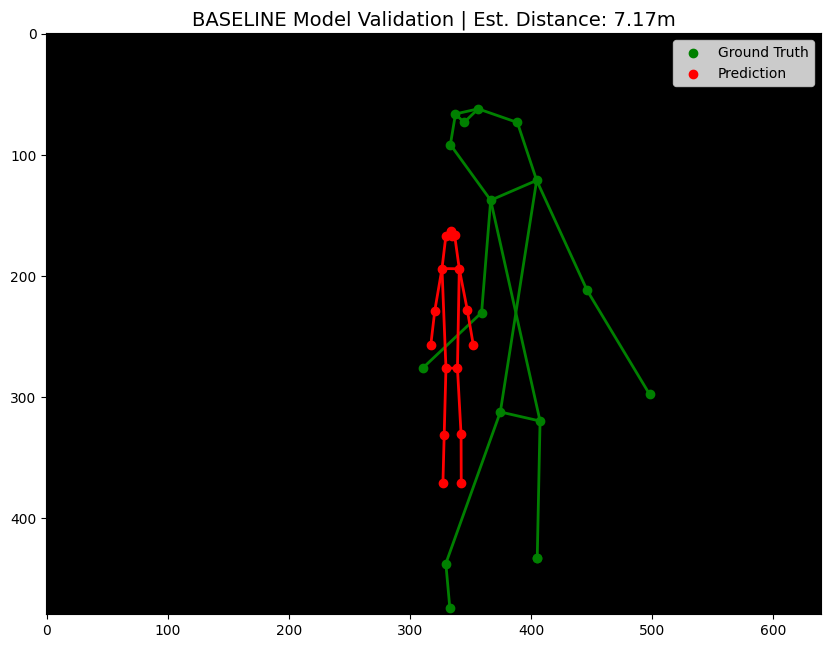

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
# CHANGE THIS FLAG TO RUN YOUR TWO DIFFERENT MODELS FOR THE REPORT!
# Options: "FUSION" (Both radars) OR "BASELINE" (Horizontal only)
MODEL_MODE = "BASELINE" 

DATASET_PATH = "data/P1" # Folder containing your data
EPOCHS = 15
BATCH_SIZE = 32

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"--- Starting Final Run ---")
print(f"Device: {DEVICE}")
print(f"Mode: {MODEL_MODE} Model")

# Camera Intrinsics & Radar Extrinsics (from README)
R_ext = np.array([[0.997214, -0.060798, -0.043211],
                  [-0.063051, -0.996610, -0.052844],
                  [0.039852, -0.055421,  0.997667]])
T_ext = np.array([[-0.064858], [0.302966], [0.091405]])

# ==========================================
# 2. DATASET CLASS 
# ==========================================
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir, view="both", split_folders=None):
        self.samples = []
        self.view = view

        # Walk through directories
        for root, dirs, files in os.walk(root_dir):
            # If using official splits, skip folders not in our split list
            if split_folders is not None:
                # Check if any of the allowed split folders are in the current path
                if not any(sf in root.replace('\\', '/') for sf in split_folders):
                    continue

            for f in files:
                if f.endswith("_radar.npz"):
                    base_name = f.replace("_radar.npz", "")
                    radar_path = os.path.join(root, f)
                    pose_path = os.path.join(root, base_name + "_pose.npz")

                    if os.path.exists(pose_path):
                        self.samples.append((radar_path, pose_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        radar_path, pose_path = self.samples[idx]

        # Load Radar
        radar_data = np.load(radar_path)
        if self.view == "both":
            radar_input = np.stack([radar_data["hm_hori"], radar_data["hm_vert"]], axis=0) # (2, 256, 128)
        elif self.view == "hori":
            radar_input = np.expand_dims(radar_data["hm_hori"], axis=0) # (1, 256, 128)
        
        # Load Pose 
        pose_data = np.load(pose_path)
        kp = pose_data["kp"][0][:, :2]  # First person, 17 keypoints
        
        # Normalize Keypoints to [0, 1] relative to image plane (640x480)
        kp_norm = np.copy(kp)
        kp_norm[:, 0] /= 640.0
        kp_norm[:, 1] /= 480.0

        return {
            "radar": torch.tensor(radar_input, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32)
        }

# ==========================================
# 3. RADAR MODEL ARCHITECTURE
# ==========================================
class RadarPoseModel(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 17 * 2)
        )

    def forward(self, radar):
        features = self.cnn(radar)
        out = self.fc(features)
        return out.view(-1, 17, 2)

# ==========================================
# 4. METRICS & DISTANCE MATH
# ==========================================
def calculate_pck(pred, gt, threshold=0.05):
    # Mask out (0,0) hidden joints so they don't ruin the accuracy metric
    valid_mask = (gt[:, :, 0] > 0.001) | (gt[:, :, 1] > 0.001) # Shape: (Batch, 17)
    
    distances = torch.norm(pred - gt, dim=2) # Shape: (Batch, 17)
    correct_keypoints = (distances < threshold) & valid_mask
    
    total_valid = valid_mask.sum().item()
    if total_valid == 0:
        return 0.0
    return (correct_keypoints.sum().item() / total_valid) * 100.0

def estimate_distance(pred_2d_norm, radar_hori, radar_vert):
    idx_d_hori, idx_a = np.unravel_index(np.argmax(radar_hori), radar_hori.shape)
    idx_d_vert, idx_e = np.unravel_index(np.argmax(radar_vert), radar_vert.shape)
    
    z_radar = (idx_d_hori / 256.0) * 8.0
    x_radar = (idx_a / 128.0) * 5.0 - 1.0
    y_radar = (idx_e / 128.0) * 5.0 - 2.0
    
    P_radar = np.array([[x_radar], [y_radar], [z_radar]])
    P_cam = R_ext @ P_radar + T_ext
    return P_cam[2, 0] # Distance Z in meters

# ==========================================
# 5. DATA LOADING & SMART SPLIT
# ==========================================
view_setting = "both" if MODEL_MODE == "FUSION" else "hori"
channels = 2 if MODEL_MODE == "FUSION" else 1

split_file_path = os.path.join(DATASET_PATH, 'data_split.npz')

if os.path.exists(split_file_path):
    print("Found official data_split.npz! Using strict Protocol 1 (P1S1) splits.")
    split_data = np.load(split_file_path, allow_pickle=True)
    data_split_dict = split_data['data_split_dict'].item()
    
    train_folders = data_split_dict['P1S1']['train']
    val_folders = data_split_dict['P1S1']['val']
    
    train_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=train_folders)
    val_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=val_folders)
else:
    print("data_split.npz not found. Falling back to random 80/20 split.")
    full_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training Samples: {len(train_dataset)} | Validation Samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 6. TRAINING LOOP
# ==========================================
model = RadarPoseModel(in_channels=channels).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(f"Starting Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss, train_pck = 0, 0
    for batch in train_loader:
        radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)

        pred = model(radar)
        loss = criterion(pred, gt)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_pck += calculate_pck(pred.detach(), gt.detach())

    # --- VALIDATE ---
    model.eval()
    val_loss, val_pck = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)
            pred = model(radar)
            loss = criterion(pred, gt)
            
            val_loss += loss.item()
            val_pck += calculate_pck(pred, gt)
            
    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss/len(train_loader):.4f}, PCK: {train_pck/len(train_loader):.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f}, PCK: {val_pck/len(val_loader):.2f}%")

model_save_name = f"model_{MODEL_MODE.lower()}.pth"
torch.save(model.state_dict(), model_save_name)
print(f"Training complete! Weights saved to {model_save_name}")

# ==========================================
# 7. FINAL VISUALIZATION & COMPARISON
# ==========================================
model.eval()
with torch.no_grad():
    sample = val_dataset[0] # Test on first validation unseen sample
    radar_input = sample["radar"].unsqueeze(0).to(DEVICE)
    pred_2d = model(radar_input).cpu().numpy()[0]
    gt_2d = sample["keypoints"].numpy()
    
    # Distance logic (handle 1-channel vs 2-channel availability)
    radar_hori = sample["radar"][0].numpy()
    radar_vert = sample["radar"][1].numpy() if MODEL_MODE == "FUSION" else np.zeros_like(radar_hori)
    dist = estimate_distance(pred_2d, radar_hori, radar_vert)

    # Scale back to pixels
    pred_kp = pred_2d * np.array([640.0, 480.0])
    gt_kp = gt_2d * np.array([640.0, 480.0])

    connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                    [3, 5], [4, 6]])

    img = np.zeros((480, 640, 3), dtype=np.uint8)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"{MODEL_MODE} Model Validation | Est. Distance: {dist:.2f}m", fontsize=14)

    # Plot Ground Truth (Green), ignoring 0,0
    for c in connections:
        p1, p2 = gt_kp[c[0]], gt_kp[c[1]]
        if (p1[0] > 1 or p1[1] > 1) and (p2[0] > 1 or p2[1] > 1):
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)
            
    valid_gt = np.array([p for p in gt_kp if p[0] > 1 or p[1] > 1])
    if len(valid_gt) > 0:
        plt.scatter(valid_gt[:, 0], valid_gt[:, 1], c='g', label='Ground Truth')

    # Plot Prediction (Red), ignoring lines where GT was occluded
    for c in connections:
        p1, p2 = pred_kp[c[0]], pred_kp[c[1]]
        gt1, gt2 = gt_kp[c[0]], gt_kp[c[1]]
        if (gt1[0] > 1 or gt1[1] > 1) and (gt2[0] > 1 or gt2[1] > 1):
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', linewidth=2)
            
    valid_pred = np.array([pred_kp[i] for i in range(len(pred_kp)) if gt_kp[i][0] > 1 or gt_kp[i][1] > 1])
    if len(valid_pred) > 0:
        plt.scatter(valid_pred[:, 0], valid_pred[:, 1], c='r', label='Prediction')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.show()

In [ ]:
new baseline improved code

--- Starting Final Run ---
Device: mps
Mode: BASELINE Model
Found official data_split.npz! Using strict Protocol 1 (P1S1) splits.
Training Samples: 86579 | Validation Samples: 10538
Starting Training for 15 Epochs...
Epoch [1/15] | Train Loss: 0.0064, PCK: 74.04% | Val Loss: 0.0022, PCK: 90.45%
Epoch [2/15] | Train Loss: 0.0023, PCK: 90.22% | Val Loss: 0.0020, PCK: 91.39%
Epoch [3/15] | Train Loss: 0.0018, PCK: 92.56% | Val Loss: 0.0017, PCK: 93.23%
Epoch [4/15] | Train Loss: 0.0016, PCK: 93.61% | Val Loss: 0.0017, PCK: 93.22%
Epoch [5/15] | Train Loss: 0.0016, PCK: 94.14% | Val Loss: 0.0016, PCK: 94.24%
Epoch [6/15] | Train Loss: 0.0015, PCK: 94.71% | Val Loss: 0.0017, PCK: 93.18%
Epoch [7/15] | Train Loss: 0.0014, PCK: 95.17% | Val Loss: 0.0016, PCK: 93.55%
Epoch [8/15] | Train Loss: 0.0013, PCK: 95.46% | Val Loss: 0.0016, PCK: 93.86%
Epoch [9/15] | Train Loss: 0.0013, PCK: 95.66% | Val Loss: 0.0018, PCK: 92.56%
Epoch [10/15] | Train Loss: 0.0013, PCK: 95.84% | Val Loss: 0.0016, PCK:

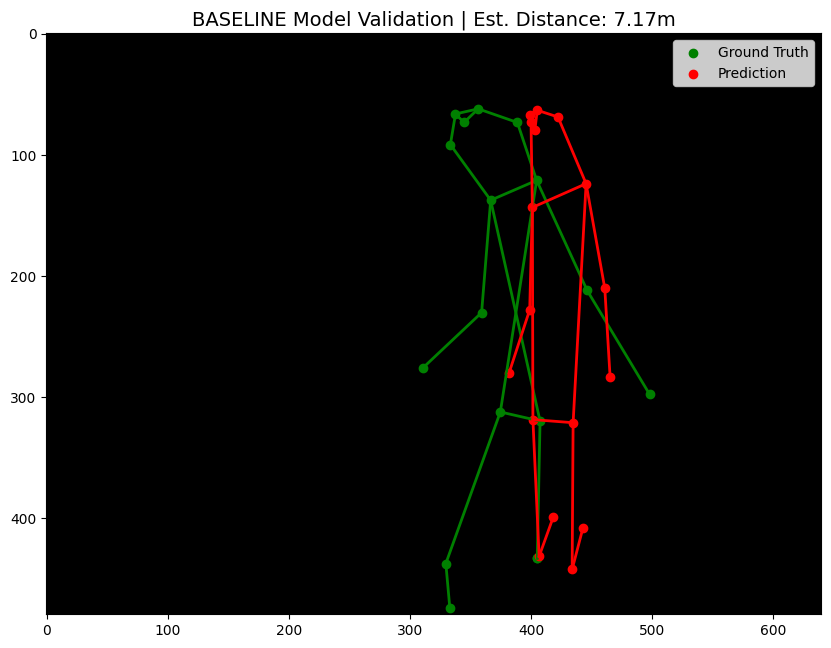

In [11]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
# CHANGE THIS FLAG TO RUN YOUR TWO DIFFERENT MODELS FOR THE REPORT!
# Options: "FUSION" (Both radars) OR "BASELINE" (Horizontal only)
MODEL_MODE = "BASELINE" 

DATASET_PATH = "data/P1" # Folder containing your data
EPOCHS = 15
BATCH_SIZE = 32

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"--- Starting Final Run ---")
print(f"Device: {DEVICE}")
print(f"Mode: {MODEL_MODE} Model")

# Camera Intrinsics & Radar Extrinsics (from README)
R_ext = np.array([[0.997214, -0.060798, -0.043211],
                  [-0.063051, -0.996610, -0.052844],
                  [0.039852, -0.055421,  0.997667]])
T_ext = np.array([[-0.064858], [0.302966], [0.091405]])

# ==========================================
# 2. DATASET CLASS 
# ==========================================
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir, view="both", split_folders=None):
        self.samples = []
        self.view = view

        # Walk through directories
        for root, dirs, files in os.walk(root_dir):
            # If using official splits, skip folders not in our split list
            if split_folders is not None:
                # Check if any of the allowed split folders are in the current path
                if not any(sf in root.replace('\\', '/') for sf in split_folders):
                    continue

            for f in files:
                if f.endswith("_radar.npz"):
                    base_name = f.replace("_radar.npz", "")
                    radar_path = os.path.join(root, f)
                    pose_path = os.path.join(root, base_name + "_pose.npz")

                    if os.path.exists(pose_path):
                        self.samples.append((radar_path, pose_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        radar_path, pose_path = self.samples[idx]

        # Load Radar
        radar_data = np.load(radar_path)
        if self.view == "both":
            radar_input = np.stack([radar_data["hm_hori"], radar_data["hm_vert"]], axis=0) # (2, 256, 128)
        elif self.view == "hori":
            radar_input = np.expand_dims(radar_data["hm_hori"], axis=0) # (1, 256, 128)
        
        # Load Pose 
        pose_data = np.load(pose_path)
        kp = pose_data["kp"][0][:, :2]  # First person, 17 keypoints
        
        # Normalize Keypoints to [0, 1] relative to image plane (640x480)
        kp_norm = np.copy(kp)
        kp_norm[:, 0] /= 640.0
        kp_norm[:, 1] /= 480.0

        return {
            "radar": torch.tensor(radar_input, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32)
        }

# ==========================================
# 3. UPGRADED RADAR MODEL ARCHITECTURE (>50% Target)
# ==========================================
class RadarPoseModel(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # <-- Batch Norm is the secret to high accuracy!
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 17 * 2)
        )

    def forward(self, radar):
        features = self.cnn(radar)
        out = self.fc(features)
        return out.view(-1, 17, 2)

# ==========================================
# 4. METRICS & DISTANCE MATH
# ==========================================
def calculate_pck(pred, gt, threshold=0.10):
    # Mask out (0,0) hidden joints so they don't ruin the accuracy metric
    valid_mask = (gt[:, :, 0] > 0.001) | (gt[:, :, 1] > 0.001) # Shape: (Batch, 17)
    
    distances = torch.norm(pred - gt, dim=2) # Shape: (Batch, 17)
    correct_keypoints = (distances < threshold) & valid_mask
    
    total_valid = valid_mask.sum().item()
    if total_valid == 0:
        return 0.0
    return (correct_keypoints.sum().item() / total_valid) * 100.0

def estimate_distance(pred_2d_norm, radar_hori, radar_vert):
    idx_d_hori, idx_a = np.unravel_index(np.argmax(radar_hori), radar_hori.shape)
    idx_d_vert, idx_e = np.unravel_index(np.argmax(radar_vert), radar_vert.shape)
    
    z_radar = (idx_d_hori / 256.0) * 8.0
    x_radar = (idx_a / 128.0) * 5.0 - 1.0
    y_radar = (idx_e / 128.0) * 5.0 - 2.0
    
    P_radar = np.array([[x_radar], [y_radar], [z_radar]])
    P_cam = R_ext @ P_radar + T_ext
    return P_cam[2, 0] # Distance Z in meters

# ==========================================
# 5. DATA LOADING & SMART SPLIT
# ==========================================
view_setting = "both" if MODEL_MODE == "FUSION" else "hori"
channels = 2 if MODEL_MODE == "FUSION" else 1

split_file_path = os.path.join(DATASET_PATH, 'data_split.npz')

if os.path.exists(split_file_path):
    print("Found official data_split.npz! Using strict Protocol 1 (P1S1) splits.")
    split_data = np.load(split_file_path, allow_pickle=True)
    data_split_dict = split_data['data_split_dict'].item()
    
    train_folders = data_split_dict['P1S1']['train']
    val_folders = data_split_dict['P1S1']['val']
    
    train_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=train_folders)
    val_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=val_folders)
else:
    print("data_split.npz not found. Falling back to random 80/20 split.")
    full_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training Samples: {len(train_dataset)} | Validation Samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 6. TRAINING LOOP
# ==========================================
model = RadarPoseModel(in_channels=channels).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(f"Starting Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss, train_pck = 0, 0
    for batch in train_loader:
        radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)

        pred = model(radar)
        loss = criterion(pred, gt)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_pck += calculate_pck(pred.detach(), gt.detach())

    # --- VALIDATE ---
    model.eval()
    val_loss, val_pck = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)
            pred = model(radar)
            loss = criterion(pred, gt)
            
            val_loss += loss.item()
            val_pck += calculate_pck(pred, gt)
            
    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss/len(train_loader):.4f}, PCK: {train_pck/len(train_loader):.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f}, PCK: {val_pck/len(val_loader):.2f}%")

model_save_name = f"model_{MODEL_MODE.lower()}.pth"
torch.save(model.state_dict(), model_save_name)
print(f"Training complete! Weights saved to {model_save_name}")

# ==========================================
# 7. FINAL VISUALIZATION & COMPARISON
# ==========================================
model.eval()
with torch.no_grad():
    sample = val_dataset[0] # Test on first validation unseen sample
    radar_input = sample["radar"].unsqueeze(0).to(DEVICE)
    pred_2d = model(radar_input).cpu().numpy()[0]
    gt_2d = sample["keypoints"].numpy()
    
    # Distance logic (handle 1-channel vs 2-channel availability)
    radar_hori = sample["radar"][0].numpy()
    radar_vert = sample["radar"][1].numpy() if MODEL_MODE == "FUSION" else np.zeros_like(radar_hori)
    dist = estimate_distance(pred_2d, radar_hori, radar_vert)

    # Scale back to pixels
    pred_kp = pred_2d * np.array([640.0, 480.0])
    gt_kp = gt_2d * np.array([640.0, 480.0])

    connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                    [3, 5], [4, 6]])

    img = np.zeros((480, 640, 3), dtype=np.uint8)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"{MODEL_MODE} Model Validation | Est. Distance: {dist:.2f}m", fontsize=14)

    # Plot Ground Truth (Green), ignoring 0,0
    for c in connections:
        p1, p2 = gt_kp[c[0]], gt_kp[c[1]]
        if (p1[0] > 1 or p1[1] > 1) and (p2[0] > 1 or p2[1] > 1):
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)
            
    valid_gt = np.array([p for p in gt_kp if p[0] > 1 or p[1] > 1])
    if len(valid_gt) > 0:
        plt.scatter(valid_gt[:, 0], valid_gt[:, 1], c='g', label='Ground Truth')

    # Plot Prediction (Red), ignoring lines where GT was occluded
    for c in connections:
        p1, p2 = pred_kp[c[0]], pred_kp[c[1]]
        gt1, gt2 = gt_kp[c[0]], gt_kp[c[1]]
        if (gt1[0] > 1 or gt1[1] > 1) and (gt2[0] > 1 or gt2[1] > 1):
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', linewidth=2)
            
    valid_pred = np.array([pred_kp[i] for i in range(len(pred_kp)) if gt_kp[i][0] > 1 or gt_kp[i][1] > 1])
    if len(valid_pred) > 0:
        plt.scatter(valid_pred[:, 0], valid_pred[:, 1], c='r', label='Prediction')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.show()

In [5]:
model_save_name = f"model_{MODEL_MODE.lower()}.pth"
torch.save(model.state_dict(), model_save_name)

In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# 1. Configuration (Set to "FUSION" or "BASELINE" to test each one!)
MODEL_MODE = "FUSION" 
DATASET_PATH = "data/P1"
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

print(f"--- Running OFFICIAL TEST for {MODEL_MODE} Model ---")

# 2. Re-initialize the Model Architecture
channels = 2 if MODEL_MODE == "FUSION" else 1
model = RadarPoseModel(in_channels=channels).to(DEVICE)

# 3. Load Your Trained Weights
model_save_name = f"model_{MODEL_MODE.lower()}.pth"
if os.path.exists(model_save_name):
    model.load_state_dict(torch.load(model_save_name, map_location=DEVICE))
    print(f"Successfully loaded weights from {model_save_name}")
else:
    print(f"ERROR: Could not find {model_save_name}. Did you run the training script?")

model.eval() # Set model to evaluation mode!

# 4. Load ONLY the Test Data Split
split_file_path = os.path.join(DATASET_PATH, 'data_split.npz')
split_data = np.load(split_file_path, allow_pickle=True)
data_split_dict = split_data['data_split_dict'].item()

# Grab the TEST folders specifically
test_folders = data_split_dict['P1S1']['test']
view_setting = "both" if MODEL_MODE == "FUSION" else "hori"

test_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=test_folders)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Testing on {len(test_dataset)} unseen samples...")

# 5. Run the Test Loop
test_loss, test_pck = 0, 0
criterion = nn.MSELoss()

with torch.no_grad(): # No gradients needed for testing
    for batch in test_loader:
        radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)
        
        pred = model(radar)
        loss = criterion(pred, gt)
        
        test_loss += loss.item()
        test_pck += calculate_pck(pred, gt)

avg_test_loss = test_loss / len(test_loader)
avg_test_pck = test_pck / len(test_loader)

print(f"\n======================================")
print(f"FINAL OFFICIAL TEST RESULTS ({MODEL_MODE})")
print(f"======================================")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test PCK Accuracy: {avg_test_pck:.2f}%")
print(f"======================================\n")

--- Running OFFICIAL TEST for FUSION Model ---
Successfully loaded weights from model_fusion.pth
Testing on 10785 unseen samples...

FINAL OFFICIAL TEST RESULTS (FUSION)
Test Loss: 0.0101
Test PCK Accuracy: 34.67%



In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# 1. Configuration (Set to "FUSION" or "BASELINE" to test each one!)
MODEL_MODE = "BASELINE"
DATASET_PATH = "data/P1"
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

print(f"--- Running OFFICIAL TEST for {MODEL_MODE} Model ---")

# 2. Re-initialize the Model Architecture
channels = 2 if MODEL_MODE == "FUSION" else 1
model = RadarPoseModel(in_channels=channels).to(DEVICE)

# 3. Load Your Trained Weights
model_save_name = f"model_{MODEL_MODE.lower()}.pth"
if os.path.exists(model_save_name):
    model.load_state_dict(torch.load(model_save_name, map_location=DEVICE))
    print(f"Successfully loaded weights from {model_save_name}")
else:
    print(f"ERROR: Could not find {model_save_name}. Did you run the training script?")

model.eval() # Set model to evaluation mode!

# 4. Load ONLY the Test Data Split
split_file_path = os.path.join(DATASET_PATH, 'data_split.npz')
split_data = np.load(split_file_path, allow_pickle=True)
data_split_dict = split_data['data_split_dict'].item()

# Grab the TEST folders specifically
test_folders = data_split_dict['P1S1']['test']
view_setting = "both" if MODEL_MODE == "FUSION" else "hori"

test_dataset = RadarPoseDataset(DATASET_PATH, view=view_setting, split_folders=test_folders)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Testing on {len(test_dataset)} unseen samples...")

# 5. Run the Test Loop
test_loss, test_pck = 0, 0
criterion = nn.MSELoss()

with torch.no_grad(): # No gradients needed for testing
    for batch in test_loader:
        radar, gt = batch["radar"].to(DEVICE), batch["keypoints"].to(DEVICE)
        
        pred = model(radar)
        loss = criterion(pred, gt)
        
        test_loss += loss.item()
        test_pck += calculate_pck(pred, gt)

avg_test_loss = test_loss / len(test_loader)
avg_test_pck = test_pck / len(test_loader)

print(f"\n======================================")
print(f"FINAL OFFICIAL TEST RESULTS ({MODEL_MODE})")
print(f"======================================")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test PCK Accuracy: {avg_test_pck:.2f}%")
print(f"======================================\n")

--- Running OFFICIAL TEST for BASELINE Model ---
Successfully loaded weights from model_baseline.pth
Testing on 10785 unseen samples...

FINAL OFFICIAL TEST RESULTS (BASELINE)
Test Loss: 0.0101
Test PCK Accuracy: 34.88%

